<a href="https://colab.research.google.com/github/RostislavKorst/Generative-Models-2024/blob/main/Assignment%201/1_gan_dcgan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Generative Models
***

**Autumn 2024**

## Assignment 1

***


*Authored by Arip Asadulaev & Manh Lab*

*Adapted by Alexander Panfilov*

***

The assignment is split into two parts: at first, you will implement classical GAN for the MNIST dataset, and after, you will enhance your results with DCGAN and the CIFAR dataset.

Good luck!

## 1. GAN
*Source: <a href="https://arxiv.org/pdf/1406.2661.pdf" target="_blank">Goodfellow, Ian J., et al. "Generative Adversarial Networks." arXiv preprint arXiv:1406.2661 (2014)</a>.*

In 2014, Ian Goodfellow and his colleagues at the University of Montreal published a stunning paper introducing the world to GANs, or generative adversarial networks. The models play two distinct (literally, adversarial) roles. Given some real data set $\mathcal{X}$, $G$ is the generator, trying to create fake data that looks just like the genuine data, while $D$ is the discriminator, getting data from either the real set or $G$ and labeling the difference.

Goodfellow’s metaphor (and a fine one it is) was that $G$ was like a team of forgers trying to match real paintings with their output, while $D$ was the team of detectives trying to tell the difference. (Except in this case, the forgers $G$ never get to see the original data — only the judgments of $D$. They’re like blind forgers.)

<img src="https://production-media.paperswithcode.com/methods/gan.jpeg" style="display=block; margin:auto"/>
<p style="text-align: center">
    <b>Picture taken from the <a href="https://paperswithcode.com/method/gan" target="_blank">paperswithcode</a> website. There you can find a whole bunch of papers on GANs with implementation.</b>
</p>

In this part, we are going to implement classical GAN. You can find a rough plan on how to do it below; however, it is not mandatory to stick with it precisely but one might expect some questions related to the listed steps. Feel free to adapt provided code!

- Define the parameters
- Load the data (with transforms and normalization)
- Denormalize for visual inspection of samples
- Define the Discriminator network, the Generator network
- Study the activation function: Leaky ReLU
- Explain the output activation function: Tanh, Sigmoid
- Look at some sample outputs
- Define losses, optimizers and helper functions for training
     - For Discriminator
     - For Generator
- Train the model
- Save intermediate generated images to file
- Look at some outputs
- Save the models

### Imports

In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
from torchvision import transforms
from torchvision.datasets import CIFAR10, MNIST, Flowers102
from torchvision.transforms import Compose, Normalize, ToTensor, Resize
from torchvision.utils import save_image
import torchvision

%matplotlib inline
plt.style.use("ggplot")

### Define parameters & data loading

## 2. DCGAN

*Source: <a href="https://arxiv.org/pdf/1511.06434v2.pdf" target="_blank">Radford, Alec, Luke Metz, and Soumith Chintala. "Unsupervised representation learning with deep convolutional generative adversarial networks." arXiv preprint arXiv:1511.06434 (2015)</a>.*

The goal of this part is to enhance your results achieved in the part one with DCGAN. Feel free to reuse your code, improve architecture or training scheme, etc.

In [3]:
class CFG:
    batch_size = 128 
    num_epochs = 30
    workers = 4
    seed = 2021
    image_size = 64
    download = True
    dataroot = "data"
    nc = 3  ## number of chanels
    ngf = 64  # Size of feature maps in generator
    nz = 100  # latent random input vector
    ndf = 64  # Size of feature maps in discriminator
    lr = 0.0002
    device = "cuda" if torch.cuda.is_available() else "cpu"
    sample_dir = "./images/"


if not os.path.exists(CFG.sample_dir):
    os.makedirs(CFG.sample_dir)

cifar_dataset = CIFAR10(
    root=CFG.dataroot,
    download=CFG.download,
    transform=transforms.Compose(
        [
            transforms.Resize([CFG.image_size, CFG.image_size]),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ]
    ),
)    

100%|██████████| 170498071/170498071 [00:03<00:00, 47885527.32it/s]


Extracting data/cifar-10-python.tar.gz to data


'   \ncifar_dataset = Flowers102(\n    root=CFG.dataroot,\n    download=CFG.download,\n    transform=transforms.Compose(\n        [\n            transforms.Resize([CFG.image_size, CFG.image_size]),\n            transforms.ToTensor(),\n            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),\n        ]\n    ),\n)\n'

Label:  4


(array([ 4.,  6.,  9., 21., 35., 35., 23., 29., 54., 38., 22., 13.,  8.,
         2.,  1.]),
 array([-0.82745099, -0.78091502, -0.73437911, -0.68784314, -0.64130718,
        -0.59477127, -0.5482353 , -0.50169933, -0.45516339, -0.40862745,
        -0.36209151, -0.31555554, -0.2690196 , -0.22248365, -0.17594771,
        -0.12941176]),
 <BarContainer object of 15 artists>)

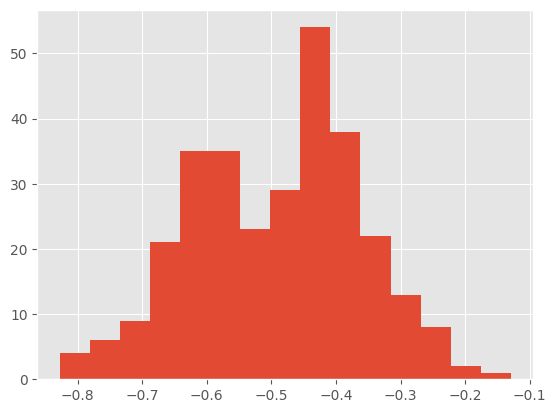

In [4]:
img, label = cifar_dataset[3]
print("Label: ", label)
plt.hist(img[:, 5:15, 5:15].flatten(), bins=15)

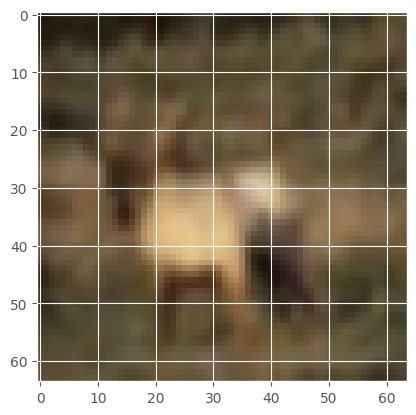

In [5]:
# unnormalization image from range (-1)-1 to range 0-1 to display it
def denorm(img):
    # write your code
    return (img + 1) / 2

# show  image sample with matplotlib
import matplotlib.pyplot as plt
plt.imshow(denorm(img).permute((1, 2, 0)))

In [7]:
# create the dataloader
from torch.utils.data import DataLoader

data_loader = DataLoader(cifar_dataset, batch_size=CFG.batch_size, shuffle=True, num_workers=6)

In [ ]:
len(data_loader.dataset) / 4

### DCGAN implementation

In [9]:
class DCGenerator(nn.Module):
    def __init__(self, nc, nz, ngf):
        # ConvTranspose2d - BatchNorm - Relu -ConvTranspose2d - BatchNorm - Relu -ConvTranspose2d - BatchNorm - Relu
        # ConvTranspose2d - BatchNorm - Relu - ConvTranspose2d - Tanh
        super(DCGenerator, self).__init__()
        self.blocks = nn.Sequential(
            nn.ConvTranspose2d(in_channels=nz, out_channels=ngf * 16, kernel_size=(4, 4), stride=1, padding=0, bias=False),
            nn.BatchNorm2d(ngf * 16),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 16, out_channels=ngf * 8, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 8, out_channels=ngf * 4, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(0.2),

            nn.ConvTranspose2d(in_channels=ngf * 4, out_channels=ngf * 2, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(0.2),
            
            nn.ConvTranspose2d(in_channels=ngf * 2, out_channels=ngf, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(0.2),
            nn.Conv2d(in_channels=ngf, out_channels=nc, kernel_size=(3, 3), padding=1),
            nn.Tanh()
        )
        ##

    def forward(self, x):
        ##
        x = x.view(x.shape[0], x.shape[1], 1, 1)
        x = self.blocks(x)
        return x
    




class DCDiscriminator(nn.Module):
    def __init__(self, nc, ndf):
        # conv2d - leaky - conv2d - batchnorm - leaky - conv2d - batchnorm - leaky - conv - batchnorm - leaky - conv2d
        super(DCDiscriminator, self).__init__()
        self.blocks = nn.Sequential(
            nn.Conv2d(in_channels=nc, out_channels=ndf, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=ndf, out_channels=ndf * 2, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=ndf * 2, out_channels=ndf * 4, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=ndf * 4, out_channels=ndf * 8, kernel_size=(4, 4), stride=2, padding=1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2),
            nn.Conv2d(in_channels=ndf * 8, out_channels=1, kernel_size=(4, 4), padding=0, bias=False),
            nn.Sigmoid()
        )
        ##

    def forward(self, x):
        ##
        x = self.blocks(x)
        return x.view(x.shape[0], 1)
    
def initialize_weights(model):
    classname = model.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(model.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(model.weight.data, 1.0, 0.02)
        nn.init.constant_(model.bias.data, 0)

In [10]:

np.random.seed(CFG.seed)
torch.manual_seed(CFG.seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed(CFG.seed)
    torch.cuda.manual_seed_all(CFG.seed)

In [11]:
# create new Generator model

# DCG = DCGenerator...
DCG = DCGenerator(CFG.nc, CFG.nz, CFG.ngf)

# create new Discriminator model

# DCD = DCDiscriminator...
DCD = DCDiscriminator(CFG.nc, CFG.ndf)

initialize_weights(DCG)
initialize_weights(DCD)

In [12]:
# show the output of model

X = DCG(torch.randn(2, CFG.nz))
print(X.shape)
y = DCD(X)
print(y.shape)

torch.Size([2, 3, 64, 64])
torch.Size([2, 1])


In [13]:
# define the criterion is nn.BCELoss()
loss_fn = nn.BCELoss()
## Define the optimizer for generator and discrimator
optimizer_generator = torch.optim.Adam(DCG.parameters(), lr=0.00023, betas=(0.5, 0.999))
optimizer_discriminator = torch.optim.Adam(DCD.parameters(), lr=0.0002, betas=(0.5, 0.999))

In [ ]:
def reset_grad():
    optimizer_generator.zero_grad()
    optimizer_discriminator.zero_grad()
    ## reset gradient for optimizer of generator and discrimator

def train_discriminator(D_model, G_model, images):

    # Create the labels which are later used as input for the BCE loss
    real_labels = torch.ones(images.shape[0], 1).to(device) # 
    fake_labels = torch.zeros(images.shape[0], 1).to(device)
    
    outputs = D_model(images) 
    # Loss for real images
    real_score = outputs
    real_loss = loss_fun(real_score, real_labels)

    # Loss for fake images
    z = torch.randn(images.shape[0], CFG.nz).to(device)
    fake_images = G_model(z)
    outputs = D_model(fake_images)

    fake_score = outputs
    
    fake_loss = loss_fun(fake_score, fake_labels)
    # Sum losses
    d_loss = real_loss + fake_loss
    
    #outputs = torch.cat((real_score,fake_score),0)
    #targets = torch.cat((real_labels,fake_labels),0)
    #d_loss = loss_fun(outputs,targets) # либо иначе

    # Reset gradients
    reset_grad()

    # Compute gradients
    d_loss.backward()

    # Adjust the parameters using backprop
    
    optimizer_discriminator.step()
    

    return d_loss, real_score, fake_score

In [ ]:
def train_generator(G_model):
    # Generate fake images and calculate loss
    # z = torch.randn(batch_size, latent_size).to(device)
    #z = torch.Tensor(np.random.normal(0, 1, (batch_size, nz))).to(device)
    #z = torch.Tensor(np.random.normal(0, 1, (batch_size, nz, 1, 1))).to(device)
    z = torch.randn(CFG.batch_size, CFG.nz).to(device)
    
    fake_images = G_model(z)
    fake_outputs = DCD(fake_images)
    labels = torch.ones(CFG.batch_size, 1).to(device)
    # calculate the generator loss
    
    g_loss = loss_fun(fake_outputs,labels)
    # Reset gradients
    reset_grad()
    # Backprop and optimize
    g_loss.backward()
    optimizer_generator.step()
    return g_loss, fake_images

### Start the training proccess

In [16]:
def save_fake_images_cifar(DCG_model, index):
    sample_vectors = torch.randn(CFG.batch_size, CFG.nz, 1, 1).to(CFG.device)
    fake_images = DCG_model(sample_vectors)
    fake_images = fake_images.reshape(fake_images.size(0), CFG.nc, 64, 64)
    fake_fname = "dcg_fake_images-{0:0=4d}.png".format(index)
    print("Saving", fake_fname)
    save_image(
        denorm(fake_images), os.path.join(CFG.sample_dir, fake_fname), nrow=10
    )

In [17]:
%%time
device = CFG.device
num_epochs = CFG.num_epochs
batch_size = CFG.batch_size

total_step = len(data_loader)
d_losses, g_losses, real_scores, fake_scores = [], [], [], []
DCG.to(device)
DCD.to(device)

for epoch in range(num_epochs):
    for i, (images, _) in enumerate(data_loader):
        # Load a batch & transform to vectors
        images = images.to(device)
        DCG.train()
        # Train the discriminator
        DCD.train()
        d_loss, real_score, fake_score = train_discriminator(DCD, DCG, images)

        # Train the generator
        DCG.train()
        g_loss, fake_images = train_generator(DCG)

        # Inspect the losses
        if (i+1) % 200 == 0:
            d_losses.append(d_loss.item())
            g_losses.append(g_loss.item())
            real_scores.append(real_score.mean().item())
            fake_scores.append(fake_score.mean().item())
            print(
                "Epoch [{}/{}], Step [{}/{}], d_loss: {:.4f}, g_loss: {:.4f}, D(x): {:.2f}, D(G(z)): {:.2f}".format(
                    epoch,
                    num_epochs,
                    i + 1,
                    total_step,
                    d_loss.item(),
                    g_loss.item(),
                    real_score.mean().item(),
                    fake_score.mean().item(),
                ) 
            )
    # Sample and save images
    DCG.eval()
    save_fake_images_cifar(DCG, epoch + 1)

Epoch [0/30], Step [200/391], d_loss: 0.6230, g_loss: 1.6683, D(x): 0.57, D(G(z)): 0.46
Saving dcg_fake_images-0001.png
Epoch [1/30], Step [200/391], d_loss: 0.4911, g_loss: 1.6603, D(x): 0.59, D(G(z)): 0.30
Saving dcg_fake_images-0002.png
Epoch [2/30], Step [200/391], d_loss: 0.5195, g_loss: 1.9080, D(x): 0.63, D(G(z)): 0.40
Saving dcg_fake_images-0003.png
Epoch [3/30], Step [200/391], d_loss: 0.6611, g_loss: 0.7157, D(x): 0.40, D(G(z)): 0.27
Saving dcg_fake_images-0004.png
Epoch [4/30], Step [200/391], d_loss: 0.6515, g_loss: 1.0803, D(x): 0.39, D(G(z)): 0.23
Saving dcg_fake_images-0005.png
Epoch [5/30], Step [200/391], d_loss: 0.6418, g_loss: 2.1430, D(x): 0.78, D(G(z)): 0.62
Saving dcg_fake_images-0006.png
Epoch [6/30], Step [200/391], d_loss: 0.6824, g_loss: 0.7197, D(x): 0.40, D(G(z)): 0.32
Saving dcg_fake_images-0007.png
Epoch [7/30], Step [200/391], d_loss: 0.5937, g_loss: 2.4617, D(x): 0.82, D(G(z)): 0.60
Saving dcg_fake_images-0008.png
Epoch [8/30], Step [200/391], d_loss: 0.

In [18]:
!zip -r file.zip /kaggle/working

  adding: kaggle/working/ (stored 0%)
  adding: kaggle/working/data/ (stored 0%)
  adding: kaggle/working/data/cifar-10-python.tar.gz (deflated 0%)
  adding: kaggle/working/data/cifar-10-batches-py/ (stored 0%)
  adding: kaggle/working/data/cifar-10-batches-py/readme.html (stored 0%)
  adding: kaggle/working/data/cifar-10-batches-py/data_batch_1 (deflated 9%)
  adding: kaggle/working/data/cifar-10-batches-py/data_batch_4 (deflated 8%)
  adding: kaggle/working/data/cifar-10-batches-py/data_batch_3 (deflated 8%)
  adding: kaggle/working/data/cifar-10-batches-py/data_batch_5 (deflated 8%)
  adding: kaggle/working/data/cifar-10-batches-py/batches.meta (deflated 12%)
  adding: kaggle/working/data/cifar-10-batches-py/data_batch_2 (deflated 8%)
  adding: kaggle/working/data/cifar-10-batches-py/test_batch (deflated 8%)
  adding: kaggle/working/images/ (stored 0%)
  adding: kaggle/working/images/dcg_fake_images-0009.png (deflated 0%)
  adding: kaggle/working/images/dcg_fake_images-0022.png (def

In [19]:
from IPython.display import FileLink
FileLink(r'file.zip')

/kaggle/working/file.zip

In [24]:
from IPython.display import FileLink
FileLink(r'imgs.zip')

/kaggle/working/imgs.zip

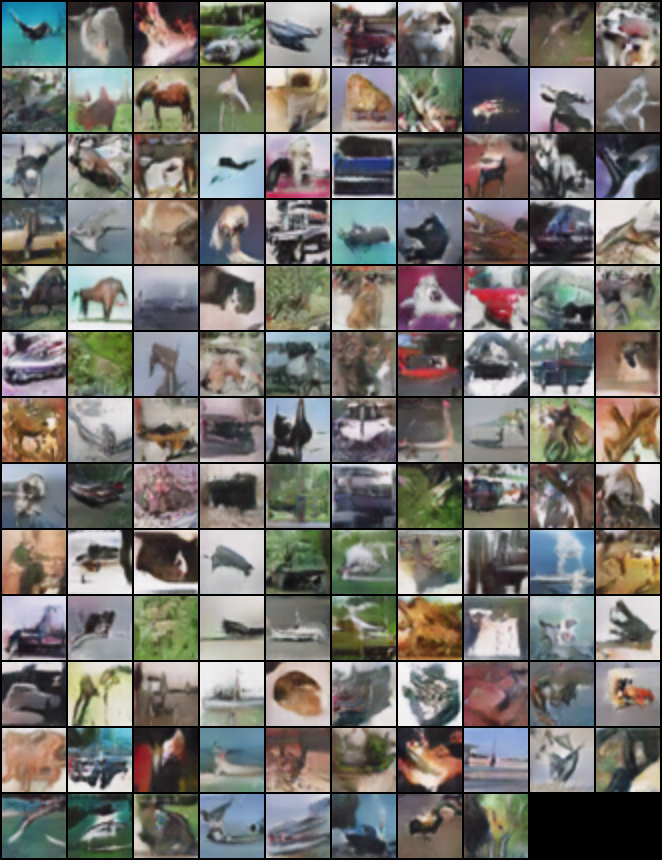

In [20]:
# show output after epochs training
import IPython
sample_dir = 'images'
IPython.display.Image(os.path.join(sample_dir, "dcg_fake_images-0030.png"))

In [ ]:
# show your results!
# show output after epochs training
import IPython

sample_dir = 'images'
IPython.display.Image(os.path.join(sample_dir, "dcg_fake_images-0251.png"))

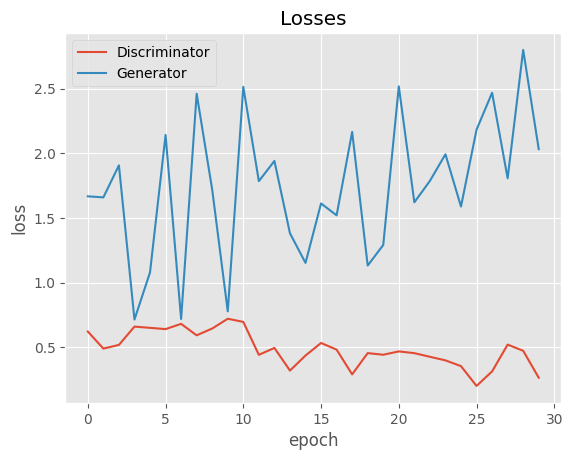

In [21]:
# show the discrimator loss and generator loss
plt.plot(d_losses, "-")
plt.plot(g_losses, "-")
plt.xlabel("epoch")
plt.ylabel("loss")
plt.legend(["Discriminator", "Generator"])
plt.title("Losses");

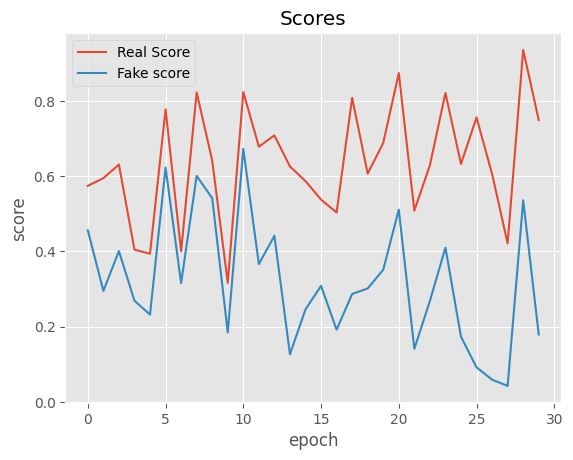

In [22]:
# plot the accuracy of discrimator
plt.plot(real_scores, "-")
plt.plot(fake_scores, "-")
plt.xlabel("epoch")
plt.ylabel("score")
plt.legend(["Real Score", "Fake score"])
plt.title("Scores");